<a href="https://colab.research.google.com/github/milicak/Data_Analysis_Course/blob/main/10_CA_fires_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install jdcal
!pip install cdsapi
import datetime
from jdcal import jd2gcal
from matplotlib import gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sqlite3
import xarray as xr

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rtatman/188-million-us-wildfires")

print("Path to dataset files:", path)

100%|██████████| 168M/168M [00:01<00:00, 160MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/rtatman/188-million-us-wildfires/versions/2


In [4]:
ls /root/.cache/kagglehub/datasets/rtatman/188-million-us-wildfires/versions/2

FPA_FOD_20170508.sqlite


In [6]:
##### 1. Loading raw data #####
input_filename = '/root/.cache/kagglehub/datasets/rtatman/188-million-us-wildfires/versions/2/FPA_FOD_20170508.sqlite'
#input_filename = '/kaggle/input/188-million-us-wildfires/FPA_FOD_20170508.sqlite'
conn = sqlite3.connect(input_filename)
query = '''
    SELECT
        NWCG_REPORTING_AGENCY, NWCG_REPORTING_UNIT_ID,
        NWCG_REPORTING_UNIT_NAME,
        FIRE_NAME,
        COMPLEX_NAME,
        FIRE_YEAR,
        DISCOVERY_DATE,
        DISCOVERY_DOY,
        DISCOVERY_TIME,
        STAT_CAUSE_CODE,
        STAT_CAUSE_DESCR,
        CONT_DATE,
        CONT_DOY,
        CONT_TIME,
        FIRE_SIZE,
        FIRE_SIZE_CLASS,
        LATITUDE,
        LONGITUDE,
        OWNER_CODE,
        OWNER_DESCR,
        STATE,
        COUNTY
    FROM
        Fires;
'''
df_raw = pd.read_sql_query(query, conn)
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1880465 entries, 0 to 1880464
Data columns (total 22 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   NWCG_REPORTING_AGENCY     object 
 1   NWCG_REPORTING_UNIT_ID    object 
 2   NWCG_REPORTING_UNIT_NAME  object 
 3   FIRE_NAME                 object 
 4   COMPLEX_NAME              object 
 5   FIRE_YEAR                 int64  
 6   DISCOVERY_DATE            float64
 7   DISCOVERY_DOY             int64  
 8   DISCOVERY_TIME            object 
 9   STAT_CAUSE_CODE           float64
 10  STAT_CAUSE_DESCR          object 
 11  CONT_DATE                 float64
 12  CONT_DOY                  float64
 13  CONT_TIME                 object 
 14  FIRE_SIZE                 float64
 15  FIRE_SIZE_CLASS           object 
 16  LATITUDE                  float64
 17  LONGITUDE                 float64
 18  OWNER_CODE                float64
 19  OWNER_DESCR               object 
 20  STATE                   

In [7]:
##### 2. Cleaning data and extracting California #####
drop_columns = ['NWCG_REPORTING_AGENCY',
                'NWCG_REPORTING_UNIT_ID',
                'NWCG_REPORTING_UNIT_NAME',
                'FIRE_NAME',
                'COMPLEX_NAME',
                'OWNER_DESCR',
                'FIRE_SIZE_CLASS',
                'OWNER_CODE']
df_CA = df_raw[df_raw.STATE == 'CA'].drop(columns=drop_columns)
#Extracting onset month and day
df_CA['MONTH'] = df_CA['DISCOVERY_DATE'].apply(lambda x: jd2gcal(x, 0)[1])
df_CA['DAY'] = df_CA['DISCOVERY_DATE'].apply(lambda x: jd2gcal(x, 0)[2])

In [8]:
df_CA

,FIRE_YEAR,DISCOVERY_DATE,DISCOVERY_DOY,DISCOVERY_TIME,STAT_CAUSE_CODE,STAT_CAUSE_DESCR,CONT_DATE,CONT_DOY,CONT_TIME,FIRE_SIZE,LATITUDE,LONGITUDE,STATE,COUNTY,MONTH,DAY
0,2005,2453403.5,33,1300,9.0,Miscellaneous,2453403.5,33.0,1730,0.10,40.036944,-121.005833,CA,63,2,2
1,2004,2453137.5,133,0845,1.0,Lightning,2453137.5,133.0,1530,0.25,38.933056,-120.404444,CA,61,5,12
2,2004,2453156.5,152,1921,5.0,Debris Burning,2453156.5,152.0,2024,0.10,38.984167,-120.735556,CA,17,5,31
3,2004,2453184.5,180,1600,1.0,Lightning,2453189.5,185.0,1400,0.10,38.559167,-119.913333,CA,3,6,28
4,2004,2453184.5,180,1600,1.0,Lightning,2453189.5,185.0,1200,0.10,38.559167,-119.933056,CA,3,6,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880460,2015,2457291.5,269,1726,13.0,Missing/Undefined,2457291.5,269.0,1843,0.01,40.481637,-122.389375,CA,None,9,26
1880461,2015,2457300.5,278,0126,9.0,Miscellaneous,NaN,NaN,None,0.20,37.617619,-120.938570,CA,None,10,5
1880462,2015,2457144.5,122,2052,13.0,Missing/Undefined,NaN,NaN,None,0.10,37.617619,-120.938570,CA,None,5,2
1880463,2015,2457309.5,287,2309,13.0,Missing/Undefined,NaN,NaN,None,2.00,37.672235,-120.898356,CA,None,10,14


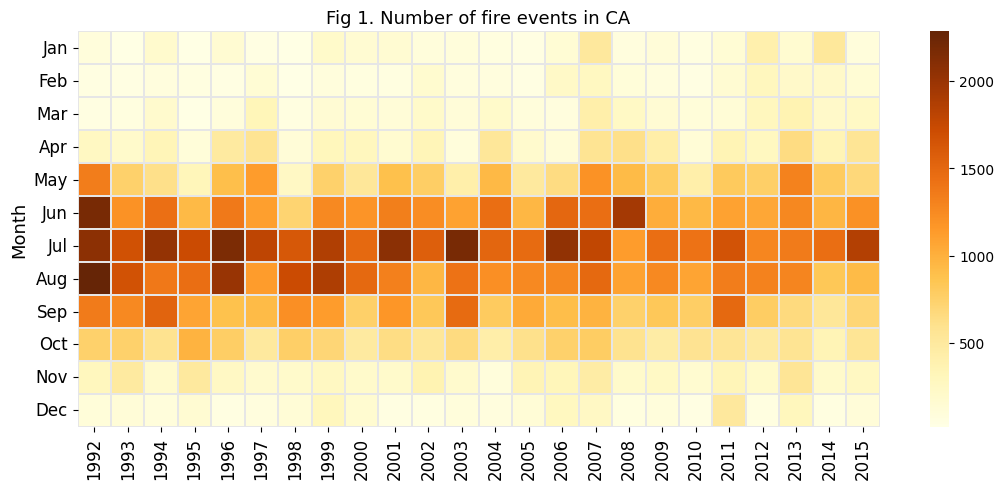

In [9]:
##### 3. Monthly/seasonal fire frequency #####
df_freq_mon = df_CA.groupby(['MONTH', 'FIRE_YEAR']).size().unstack()
# plot monthly frequency of fire events
counter_fig = 1
mon_ticks = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.figure(figsize=[11,5])
sns.heatmap(df_freq_mon, cmap='YlOrBr', linewidth=.2, linecolor=[.9,.9,.9])
plt.yticks(np.arange(0.5,12.5), labels=mon_ticks, rotation=0, fontsize=12)
plt.xticks(fontsize=12);
plt.xlabel('')
plt.ylabel('Month', fontsize=13)
plt.title(f'Fig {counter_fig}. Number of fire events in CA', fontsize=13)
plt.tight_layout()

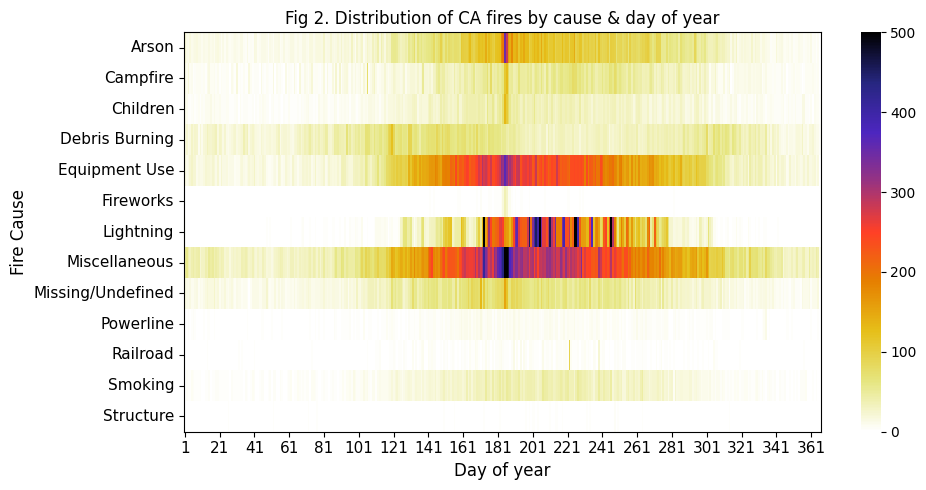

In [10]:
# plot fire frequency by cause and day of year
cause_by_doy = df_CA.groupby(['STAT_CAUSE_DESCR','DISCOVERY_DOY']).size().unstack()
counter_fig +=1
plt.figure(figsize=[10,5])
ax = sns.heatmap(cause_by_doy,cmap='CMRmap_r',vmin=0,vmax=500)
plt.xticks(np.arange(0.5,366.5,20), labels=range(1,366,20), rotation=0, fontsize=11)
plt.yticks(fontsize=11)
plt.ylabel('Fire Cause', fontsize=12)
plt.xlabel('Day of year', fontsize=12)
for borders in ["top","right","left","bottom"]:
    ax.spines[borders].set_visible(True)
plt.title(f'Fig {counter_fig}. Distribution of CA fires by cause & day of year')
plt.tight_layout()

In [12]:
from google.colab import files
uploaded = files.upload()

Saving apikey to apikey


In [14]:
import os
!rm -f ERA5_monthly.nc
##### 4. Download and extract climate data (ERA5) #####
import cdsapi

def _read_api_key_from_file(filepath):
    api_key = None
    api_url = None
    try:
        with open(filepath, 'r') as f:
            for line in f:
                if line.startswith('url:'):
                    api_url = line.split(':', 1)[1].strip()
                elif line.startswith('key:'):
                    api_key = line.split(':', 1)[1].strip()
    except FileNotFoundError:
        print(f"Error: apikey file not found at {filepath}")
    return api_key, api_url

def _download_era5(variables :list, filename: str):
    apikey, url = _read_api_key_from_file('apikey')
    if not apikey or not url:
        print("Error: Could not retrieve API key or URL from 'apikey' file.")
        return

    c = cdsapi.Client(key=apikey, url=url)
    c.retrieve('reanalysis-era5-single-levels-monthly-means',
               {'format': 'netcdf',
                'product_type': 'monthly_averaged_reanalysis',
                'variable': variables,
                'year': [f'{yr}' for yr in range(1992,2016)],
                'month': [f'{x:02.0f}' for x in range(1,13)],
                'time': '00:00',
                'area': [42, -124, 32.5,-115],
               },
               f'{filename}.nc')

#vars_all = ['total_precipitation', '2m_temperature', '2m_dewpoint_temperature',
#           '10m_wind_speed', 'volumetric_soil_water_layer_1','potential_evaporation']
vars_all = ['2m_temperature']

# Read API key and URL from the uploaded file
apikey, url = _read_api_key_from_file('apikey')
if not apikey or not url:
    print("Error: Could not retrieve API key or URL from 'apikey' file. Please ensure it's uploaded correctly.")
else:
    c = cdsapi.Client(key=apikey, url=url)
    _download_era5(vars_all, 'ERA5_monthly')
    ds_era5 = xr.open_dataset('ERA5_monthly.nc')

2026-04-27 16:01:34,578 INFO Request ID is 9d304961-829a-4fa2-bdb5-ee2a1619d9cd
INFO:ecmwf.datastores.legacy_client:Request ID is 9d304961-829a-4fa2-bdb5-ee2a1619d9cd
2026-04-27 16:01:34,781 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-04-27 16:01:48,953 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-04-27 16:02:28,068 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


e19710ee205cbe90f50c0bb3a16e347e.nc:   0%|          | 0.00/731k [00:00<?, ?B/s]

In [15]:
ds_era5

<xarray.Dataset> Size: 2MB
Dimensions:     (valid_time: 288, latitude: 39, longitude: 37)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2kB 1992-01-01 ... 2015-12-01
  * latitude    (latitude) float64 312B 42.0 41.75 41.5 ... 33.0 32.75 32.5
  * longitude   (longitude) float64 296B -124.0 -123.8 -123.5 ... -115.2 -115.0
    number      int64 8B ...
    expver      (valid_time) <U4 5kB ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 2MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-27T16:02 GRIB to CDM+CF via cfgrib-0.9.1...

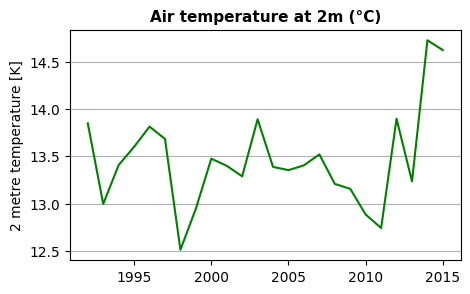

In [16]:
##### 5. Assessing climate trends #####
# plot climate trends
counter_fig +=1
var = list(ds_era5.data_vars)
titles = {"t2m":"Air temperature at 2m (°C)"}
unit_conversion = {"t2m": [1,-273.15]}
fig = plt.figure(figsize=(13, 5.5))
gs = gridspec.GridSpec(2, 3)
for i in range(len(var)):
    plt.subplot(gs[i])
    #(ds_era5[var[i]].where(CA_mask).mean(['latitude','longitude']).groupby(
    (ds_era5[var[i]].mean(['latitude','longitude']).groupby(
        ds_era5.valid_time.dt.year).mean()*unit_conversion[var[i]][0] + \
        unit_conversion[var[i]][1]).plot(color='g')
    plt.xlabel('')
    plt.grid(axis='y')
    plt.title(titles[var[i]], fontsize=11, fontweight='bold')
plt.tight_layout()

In [17]:
##### 6. Assessing the climate factors affecting fires #####
df_freq = pd.DataFrame(df_CA.groupby(['FIRE_YEAR','MONTH']).size(), columns=['Frequency'])
df_freq = df_freq.reset_index().rename(columns={'FIRE_YEAR':'Year', 'MONTH':'Month'})
# extract monthly ERA5 data
def extract_era5_yr_mon(yr, mon, var):
    unit_conversion = {"t2m": [1,-273.15]}
    ds_yr_mon = ds_era5.sel(valid_time = ds_era5.valid_time.dt.month.isin(mon) & ds_era5.valid_time.dt.year.isin(yr))
    output = float(ds_yr_mon[var].mean(['latitude','longitude']).values) * \
    unit_conversion[var][0] + unit_conversion[var][1]
    return output


/tmp/ipykernel_3051/1657213128.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  output = float(ds_yr_mon[var].mean(['latitude','longitude']).values) * \
/tmp/ipykernel_3051/1657213128.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  output = float(ds_yr_mon[var].mean(['latitude','longitude']).values) * \
/tmp/ipykernel_3051/1657213128.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  output = float(ds_yr_mon[var].mean(['latitude','longitude']).values) * \
/

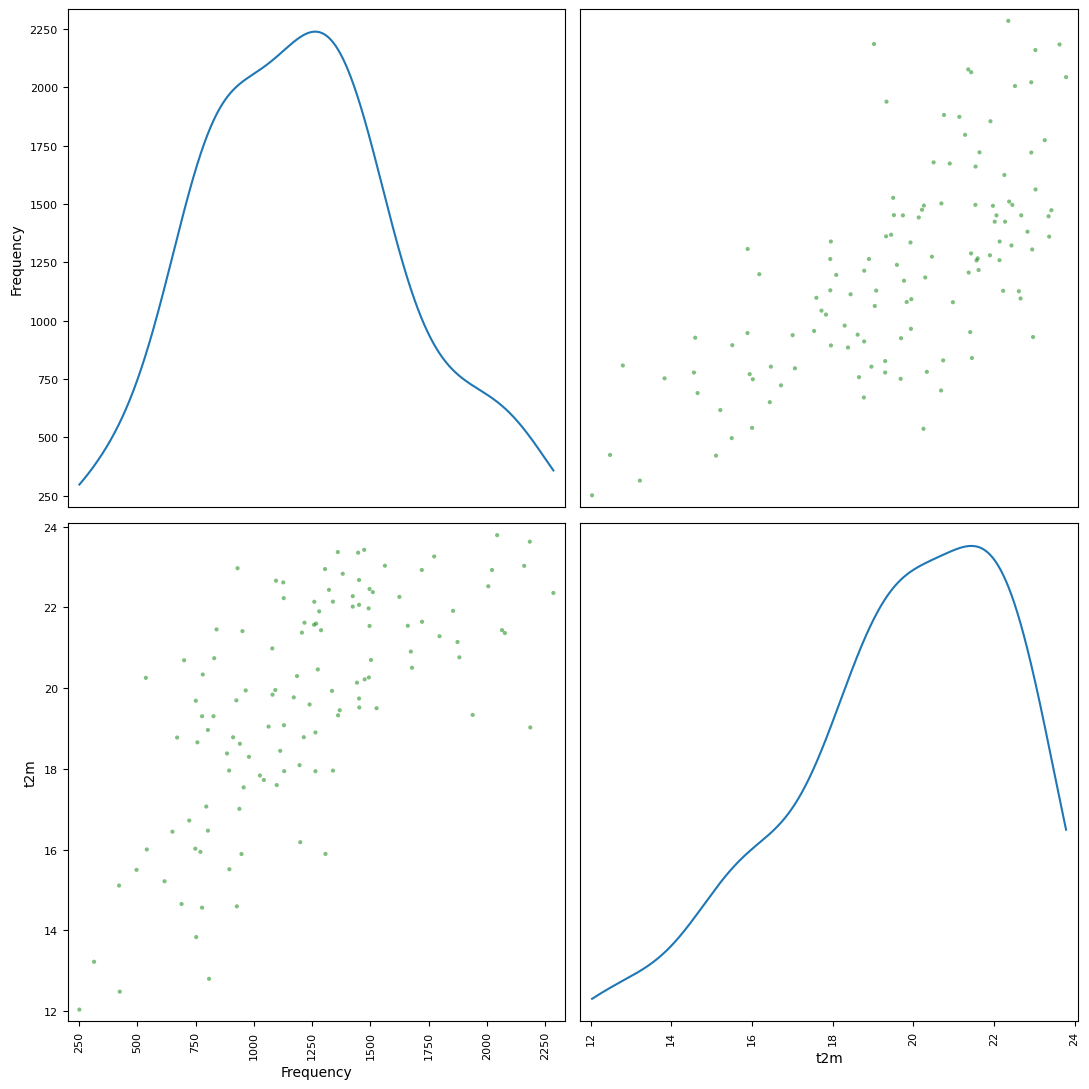

In [18]:
# adding climate data to the dataframe
for i in range(len(var)):
    df_freq[var[i]] = df_freq.apply(lambda x: extract_era5_yr_mon(x.Year, x.Month, var[i]), axis=1)

# plotting scatter matrix for summer (MJJAS)
#plt.style.use('seaborn')
counter_fig +=1
df_freq_summer = df_freq[df_freq.Month.isin([5,6,7,8,9])]
pd.plotting.scatter_matrix(df_freq_summer.drop(
    columns=['Year','Month']), alpha=0.5, color='g', figsize=(11, 11), diagonal='kde',);
plt.tight_layout()


In [19]:
##### 7. Setup the ANN model #####
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.callbacks import EarlyStopping

In [21]:
def ANN_fit(X,y):
    # temporal split into train and test
    ind_split = int(len(y)*.7)
    X_train = X[:ind_split];    X_test = X[ind_split:]
    y_train = y[:ind_split];    y_test = y[ind_split:]

    # scaling data
    scaler = MinMaxScaler()
    scaler.fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)

    # setting up and fitting the model
    early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=100)
    model = Sequential()
    model.add(Dense(16,activation='relu'))
    model.add(Dense(16,activation='relu'))
    model.add(Dense(8,activation='relu'))
    #model.add(Dense(4,activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    history = model.fit(X_train, y_train, epochs=3500, validation_data=(X_test, y_test),
                        verbose=0, shuffle=False, callbacks=[early_stop])

    # plotting the loss function
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='test')
    plt.legend()
    plt.show()

    # predicting the test period
    test_predictions = model.predict(X_test)
    test_predictions = pd.Series(test_predictions.reshape(test_predictions.shape[0], ))
    pred_df = pd.DataFrame(y_test, columns=['Test True Y'])
    pred_df = pd.concat([pred_df, test_predictions], axis=1)
    pred_df.columns = ['Test True Y', 'Model Prediction']
    pred_df['Year'] = df_freq[ind_split:].Year.values
    pred_df['Month'] = df_freq[ind_split:].Month.values

    return pred_df


In [22]:
def ANN_fit_single(X,y):
    # temporal split into train and test
    ind_split = int(len(y)*.7)
    X_train = X[:ind_split];    X_test = X[ind_split:]
    y_train = y[:ind_split];    y_test = y[ind_split:]

    # scaling data
    scaler = MinMaxScaler()
    scaler.fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)

    # setting up and fitting the model
    early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=100)
    model = Sequential()
    model.add(Dense(16,activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    history = model.fit(X_train, y_train, epochs=3500, validation_data=(X_test, y_test),
                        verbose=0, shuffle=False, callbacks=[early_stop])

    # plotting the loss function
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='test')
    plt.legend()
    plt.show()

    # predicting the test period
    test_predictions = model.predict(X_test)
    test_predictions = pd.Series(test_predictions.reshape(test_predictions.shape[0], ))
    pred_df = pd.DataFrame(y_test, columns=['Test True Y'])
    pred_df = pd.concat([pred_df, test_predictions], axis=1)
    pred_df.columns = ['Test True Y', 'Model Prediction']
    pred_df['Year'] = df_freq[ind_split:].Year.values
    pred_df['Month'] = df_freq[ind_split:].Month.values

    return pred_df

In [23]:
##################################################
##### 8. Fitting the ANN model #####
plt.style.use('ggplot')
y = df_freq['Frequency'].values
X = df_freq.drop(columns=['Frequency']).values


In [26]:
df_freq

,Year,Month,Frequency,t2m
0,1992,1,92,5.015741
1,1992,2,54,8.599512
2,1992,3,48,9.920374
3,1992,4,259,14.226617
4,1992,5,1339,17.957300
...,...,...,...,...
283,2015,8,930,22.971490
284,2015,9,701,20.690729
285,2015,10,565,16.858392
286,2015,11,263,7.741846


Epoch 539: early stopping


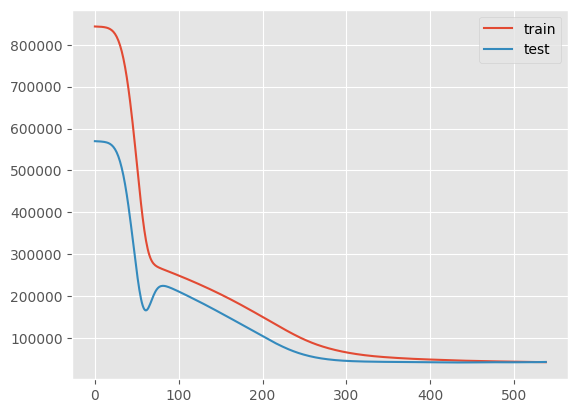

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [32]:
pred_df = ANN_fit(X, y)

Epoch 599: early stopping


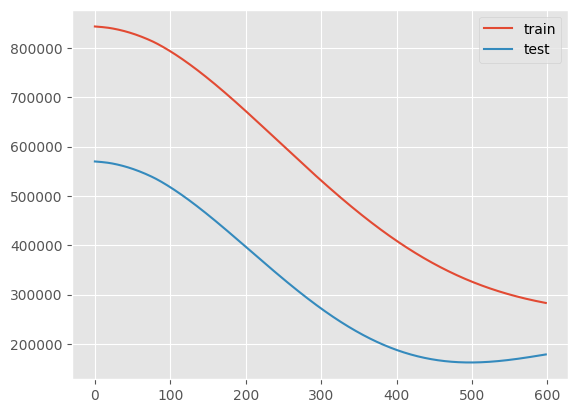

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [27]:
pred_df_single = ANN_fit_single(X, y)

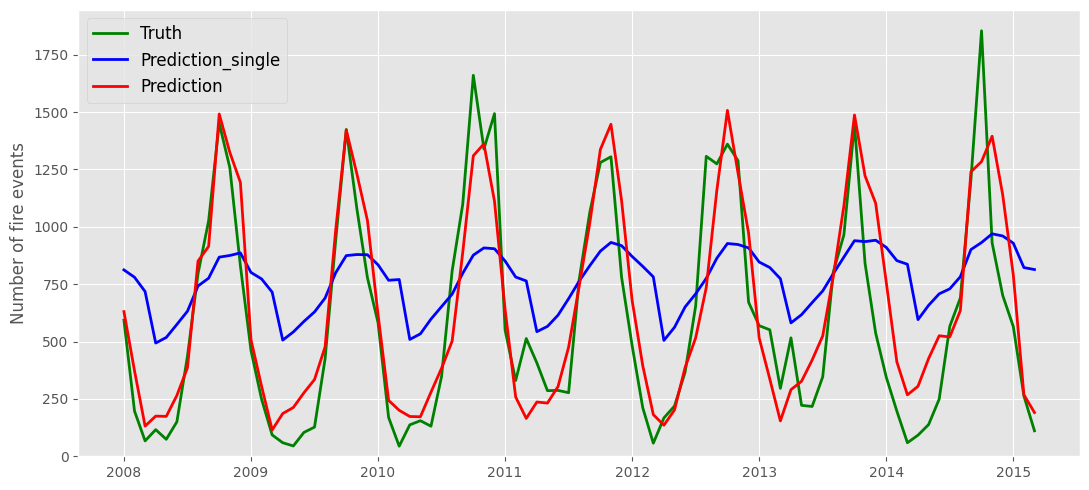

In [33]:
counter_fig +=1
plt.figure(figsize=[11,5])
plt.plot(pred_df['Test True Y'], color='g', linewidth=2, label='Truth')
plt.plot(pred_df_single['Model Prediction'], color='b', linewidth=2, label='Prediction_single')
plt.plot(pred_df['Model Prediction'], color='r', linewidth=2, label='Prediction')
plt.xticks(ticks=range(0,len(pred_df),12), labels=pred_df.Year[::12])
plt.ylim(bottom=0)
plt.ylabel('Number of fire events', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()

In [ ]:
df_freq

,Year,Month,Frequency,t2m
0,1992,1,92,5.015741
1,1992,2,54,8.599512
2,1992,3,48,9.920374
3,1992,4,259,14.226617
4,1992,5,1339,17.957300
...,...,...,...,...
283,2015,8,930,22.971490
284,2015,9,701,20.690729
285,2015,10,565,16.858392
286,2015,11,263,7.741846


In [ ]:
X

array([[1.99200000e+03, 1.00000000e+00, 5.01574097e+00],
       [1.99200000e+03, 2.00000000e+00, 8.59951172e+00],
       [1.99200000e+03, 3.00000000e+00, 9.92040405e+00],
       [1.99200000e+03, 4.00000000e+00, 1.42266174e+01],
       [1.99200000e+03, 5.00000000e+00, 1.79572693e+01],
       [1.99200000e+03, 6.00000000e+00, 1.90263916e+01],
       [1.99200000e+03, 7.00000000e+00, 2.14373718e+01],
       [1.99200000e+03, 8.00000000e+00, 2.23582703e+01],
       [1.99200000e+03, 9.00000000e+00, 1.93265625e+01],
       [1.99200000e+03, 1.00000000e+01, 1.56785522e+01],
       [1.99200000e+03, 1.10000000e+01, 8.75426636e+00],
       [1.99200000e+03, 1.20000000e+01, 3.92061768e+00],
       [1.99300000e+03, 1.00000000e+00, 4.00164185e+00],
       [1.99300000e+03, 2.00000000e+00, 5.63305054e+00],
       [1.99300000e+03, 3.00000000e+00, 1.02574707e+01],
       [1.99300000e+03, 4.00000000e+00, 1.19526001e+01],
       [1.99300000e+03, 5.00000000e+00, 1.60227600e+01],
       [1.99300000e+03, 6.00000

In [72]:
import os
# !pip install netcdf4
!rm -f ERA5_monthly.nc
##### 4. Download and extract climate data (ERA5) #####
import cdsapi

def _read_api_key_from_file(filepath):
    api_key = None
    api_url = None
    try:
        with open(filepath, 'r') as f:
            for line in f:
                if line.startswith('url:'):
                    api_url = line.split(':', 1)[1].strip()
                elif line.startswith('key:'):
                    api_key = line.split(':', 1)[1].strip()
    except FileNotFoundError:
        print(f"Error: apikey file not found at {filepath}")
    return api_key, api_url

def _download_era5(variables :list, filename: str):
    apikey, url = _read_api_key_from_file('apikey')
    if not apikey or not url:
        print("Error: Could not retrieve API key or URL from 'apikey' file.")
        return

    c = cdsapi.Client(key=apikey, url=url)
    c.retrieve('reanalysis-era5-single-levels-monthly-means',
               {'format': 'netcdf', # Changed from 'netcdf.zip' to 'netcdf'
                'product_type': 'monthly_averaged_reanalysis',
                'variable': variables,
                'year': [f'{yr}' for yr in range(1992,2016)],
                'month': [f'{x:02.0f}' for x in range(1,13)],
                'time': '00:00',
                'area': [42, -124, 32.5,-115],
               },
               f'{filename}.nc')

#vars_all = ['total_precipitation', '2m_temperature', '2m_dewpoint_temperature',
#           '10m_wind_speed', 'volumetric_soil_water_layer_1','potential_evaporation']
vars_all = ['total_precipitation', '2m_temperature', '2m_dewpoint_temperature',
           '10m_wind_speed', 'volumetric_soil_water_layer_1','potential_evaporation']

# Read API key and URL from the uploaded file
apikey, url = _read_api_key_from_file('apikey')
if not apikey or not url:
    print("Error: Could not retrieve API key or URL from 'apikey' file. Please ensure it's uploaded correctly.")
else:
    c = cdsapi.Client(key=apikey, url=url)
    _download_era5(vars_all, 'ERA5_monthly')
    #ds_era5 = xr.open_dataset('ERA5_monthly.nc') # Uncommented to open the single .nc file

2026-04-27 17:25:30,689 INFO Request ID is 6fd86a4e-d6e0-4180-bd33-8e2f8ba56fc9
INFO:ecmwf.datastores.legacy_client:Request ID is 6fd86a4e-d6e0-4180-bd33-8e2f8ba56fc9
2026-04-27 17:25:30,865 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-04-27 17:26:47,496 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


218feaf3daa9216f846db5c813843762.zip:   0%|          | 0.00/4.53M [00:00<?, ?B/s]

In [73]:
!file ERA5_monthly.nc

ERA5_monthly.nc: Zip archive data, at least v2.0 to extract, compression method=deflate


In [ ]:
os.rename('ERA5_monthly.nc', 'ERA5_monthly.zip')

In [77]:
# 2. Create a directory and extract the contents
extract_dir = 'ERA5_extracted'
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile('ERA5_monthly.zip', 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Files extracted: {os.listdir(extract_dir)}")

# 3. Load the extracted file(s)
# Using open_mfdataset safely handles the folder whether CDS gave you one .nc file or several
ds_era5 = xr.open_mfdataset(f'{extract_dir}/*.nc', combine='by_coords')

print(ds_era5)



Files extracted: ['data_stream-moda_stepType-avgad.nc', 'data_stream-moda_stepType-avgua.nc']
<xarray.Dataset> Size: 20MB
Dimensions:     (valid_time: 576, latitude: 39, longitude: 37)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 5kB 1992-01-01 ... 2015-12-01T06:...
  * latitude    (latitude) float64 312B 42.0 41.75 41.5 ... 33.0 32.75 32.5
  * longitude   (longitude) float64 296B -124.0 -123.8 -123.5 ... -115.2 -115.0
    number      int64 8B 0
    expver      (valid_time) object 5kB dask.array<chunksize=(288,), meta=np.ndarray>
Data variables:
    tp          (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(288, 39, 37), meta=np.ndarray>
    pev         (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(288, 39, 37), meta=np.ndarray>
    t2m         (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(288, 39, 37), meta=np.ndarray>
    d2m         (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(288, 39

/tmp/ipykernel_3051/1855173723.py:12: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'valid_time' ('valid_time',) The recommendation is to set join explicitly for this case.
  ds_era5 = xr.open_mfdataset(f'{extract_dir}/*.nc', combine='by_coords')
/tmp/ipykernel_3051/1855173723.py:12: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_era5 = xr.open_mfdataset(f'{extract_dir}/*.nc', combine='by_coords')
/tmp/ipykernel_3051/1855

In [76]:
# !rm ERA5_extracted/*

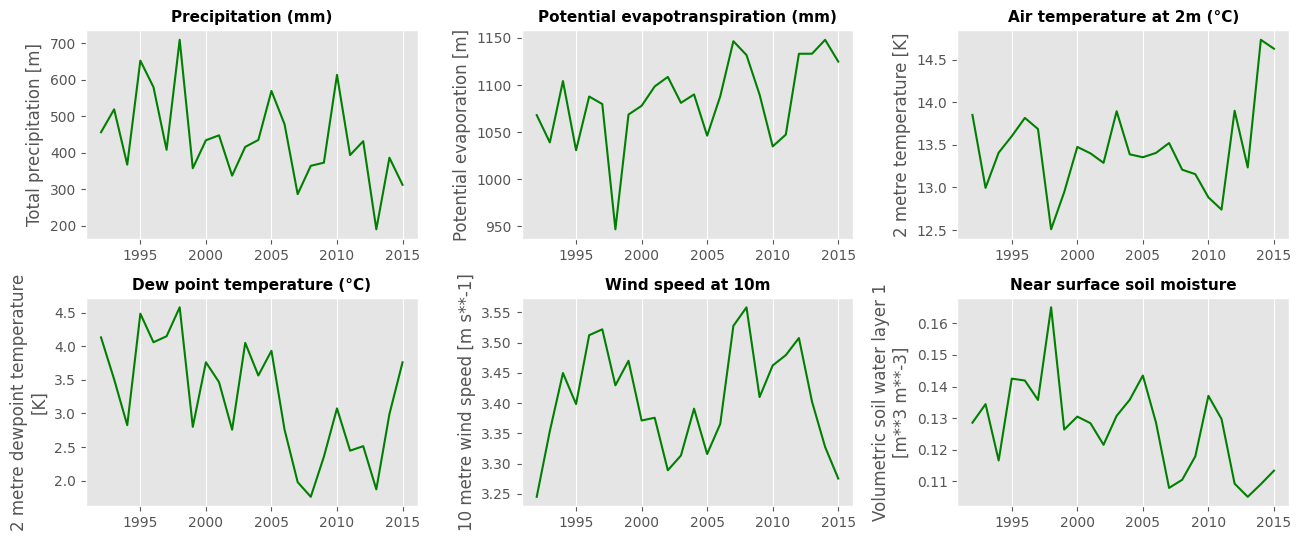

In [88]:
##### 5. Assessing climate trends #####
# plot climate trends
counter_fig +=1
var = list(ds_era5.data_vars)
titles = {"tp":"Precipitation (mm)",
         "t2m":"Air temperature at 2m (°C)",
         "d2m":"Dew point temperature (°C)",
         "si10":"Wind speed at 10m",
         "swvl1":"Near surface soil moisture",
         "pev":"Potential evapotranspiration (mm)"}
unit_conversion = {"tp": [1000*365,0], #convert default units to mm and °C -->[*multiply, *add]
                   "t2m": [1,-273.15],
                   "d2m": [1,-273.15],
                   "si10": [1,0],
                   "swvl1": [1,0],
                   "pev": [-1000*365,0]}
fig = plt.figure(figsize=(13, 5.5))
gs = gridspec.GridSpec(2, 3)
for i in range(len(var)):
    plt.subplot(gs[i])
    (ds_era5[var[i]].mean(['latitude','longitude']).groupby(
        ds_era5.valid_time.dt.year).mean()*unit_conversion[var[i]][0] + \
        unit_conversion[var[i]][1]).plot(color='g')
    plt.xlabel('')
    plt.grid(axis='y')
    plt.title(titles[var[i]], fontsize=11, fontweight='bold')
plt.tight_layout()

In [89]:
# Assessing the climate factors affecting fires #####
df_freq = pd.DataFrame(df_CA.groupby(['FIRE_YEAR','MONTH']).size(), columns=['Frequency'])
df_freq = df_freq.reset_index().rename(columns={'FIRE_YEAR':'Year', 'MONTH':'Month'})
# extract monthly ERA5 data
def extract_era5_yr_mon(yr, mon, var):
    unit_conversion = {"tp": [1000*30,0], #convert default units to mm and °C -->[*multiply, +add]
                       "t2m": [1,-273.15],
                       "d2m": [1,-273.15],
                       "si10": [1,0],
                       "swvl1": [1,0],
                       "pev": [-1000*30,0]}
    ds_yr_mon = ds_era5.sel(valid_time = ds_era5.valid_time.dt.month.isin(mon) & ds_era5.valid_time.dt.year.isin(yr))
    output = float(ds_yr_mon[var].mean(['latitude','longitude']).mean('valid_time').values) * \
    unit_conversion[var][0] + unit_conversion[var][1]
    return output

# adding climate data to the dataframe
for i in range(len(var)):
    df_freq[var[i]] = df_freq.apply(lambda x: extract_era5_yr_mon(x.Year, x.Month, var[i]), axis=1)

In [91]:
df_freq

,Year,Month,Frequency,tp,pev,t2m,d2m,si10,swvl1
0,1992,1,92,35.612143,24.106671,5.015741,-0.748389,2.985812,0.194053
1,1992,2,54,107.615541,34.762875,8.599512,3.350305,3.148899,0.218198
2,1992,3,48,81.172634,54.133935,9.920374,3.935419,3.075717,0.198555
3,1992,4,259,17.192071,102.481863,14.226617,3.697382,3.563277,0.129985
4,1992,5,1339,8.255727,139.030237,17.957300,5.555048,3.309920,0.084804
...,...,...,...,...,...,...,...,...,...
283,2015,8,930,4.531163,155.102732,22.971490,7.764276,3.290849,0.066532
284,2015,9,701,9.420677,120.221036,20.690729,5.981531,3.111632,0.068971
285,2015,10,565,24.796603,71.328152,16.858392,7.830652,3.045079,0.103203
286,2015,11,263,37.024571,37.096938,7.741846,-0.241461,3.505068,0.147112


Epoch 2127: early stopping


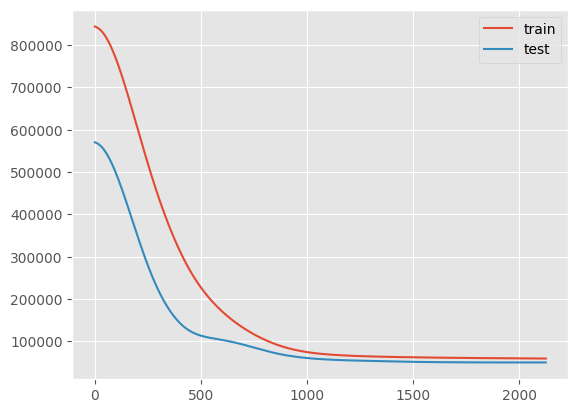

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [95]:
y = df_freq['Frequency'].values
X = df_freq.drop(columns=['Frequency']).values
pred_df_single = ANN_fit_single(X, y)

In [94]:
pred_df = ANN_fit(X, y)

array([[1.99200000e+03, 1.00000000e+00, 5.01574097e+00],
       [1.99200000e+03, 2.00000000e+00, 8.59951172e+00],
       [1.99200000e+03, 3.00000000e+00, 9.92037354e+00],
       [1.99200000e+03, 4.00000000e+00, 1.42266174e+01],
       [1.99200000e+03, 5.00000000e+00, 1.79572998e+01],
       [1.99200000e+03, 6.00000000e+00, 1.90263611e+01],
       [1.99200000e+03, 7.00000000e+00, 2.14373718e+01],
       [1.99200000e+03, 8.00000000e+00, 2.23582397e+01],
       [1.99200000e+03, 9.00000000e+00, 1.93265625e+01],
       [1.99200000e+03, 1.00000000e+01, 1.56785522e+01],
       [1.99200000e+03, 1.10000000e+01, 8.75426636e+00],
       [1.99200000e+03, 1.20000000e+01, 3.92061768e+00],
       [1.99300000e+03, 1.00000000e+00, 4.00164185e+00],
       [1.99300000e+03, 2.00000000e+00, 5.63305054e+00],
       [1.99300000e+03, 3.00000000e+00, 1.02574707e+01],
       [1.99300000e+03, 4.00000000e+00, 1.19526001e+01],
       [1.99300000e+03, 5.00000000e+00, 1.60227600e+01],
       [1.99300000e+03, 6.00000

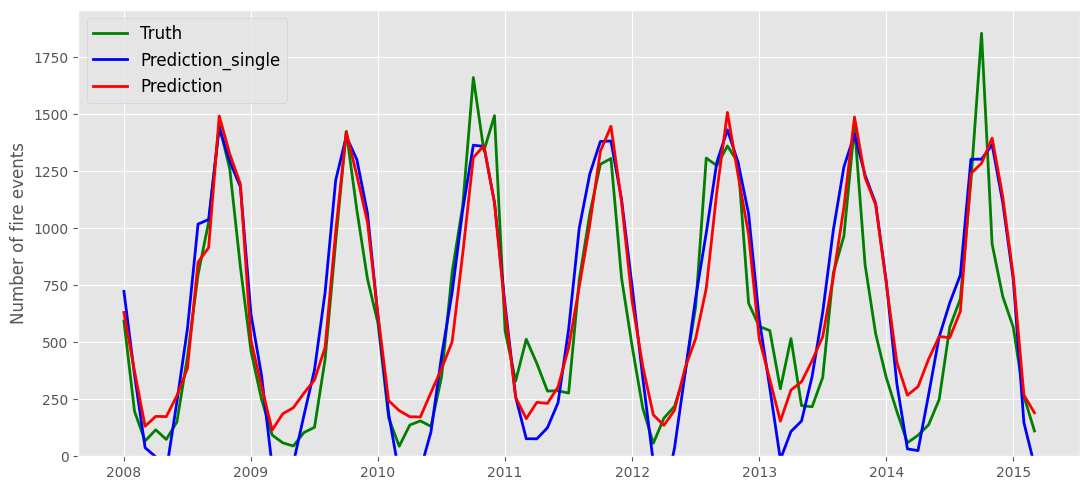

In [96]:
counter_fig +=1
plt.figure(figsize=[11,5])
plt.plot(pred_df['Test True Y'], color='g', linewidth=2, label='Truth')
plt.plot(pred_df_single['Model Prediction'], color='b', linewidth=2, label='Prediction_single')
plt.plot(pred_df['Model Prediction'], color='r', linewidth=2, label='Prediction')
plt.xticks(ticks=range(0,len(pred_df),12), labels=pred_df.Year[::12])
plt.ylim(bottom=0)
plt.ylabel('Number of fire events', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()